## Import Libraries

In [1]:
from pathlib import Path
import sys
import importlib
import itertools
import warnings
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

try:
    import tensorflow as tf
    from tensorflow.keras import Sequential
    from tensorflow.keras.layers import Dense, Dropout, Input
    from tensorflow.keras.callbacks import EarlyStopping
    from tensorflow.keras.optimizers import Adam

    tf.keras.utils.set_random_seed(RANDOM_STATE)
    print("TensorFlow version:", tf.__version__)
except ImportError as exc:
    raise ImportError(
        "TensorFlow is required for the Multilayer ANN. "
        "Install it with `pip install tensorflow`, restart the kernel, "
        "and run the notebook again."
    ) from exc

TensorFlow version: 2.21.0


## Locate the project and reuse the updated preprocessing pipeline

In [2]:
current_dir = Path.cwd().resolve()

candidate_roots = [
    current_dir,
    current_dir.parent,
    current_dir.parent.parent,
]

project_root = next(
    (
        path
        for path in candidate_roots
        if (
            path / "data" / "raw" /
            "GlobalLandTemperaturesByCountry.csv"
        ).exists()
        and (path / "code" / "preprocess.py").exists()
    ),
    None
)

if project_root is None:
    raise FileNotFoundError(
        "Cannot find the project root. Expected both:\n"
        "  data/raw/GlobalLandTemperaturesByCountry.csv\n"
        "  code/preprocess.py\n"
        "Place this notebook inside the same project used by "
        "01_data_preprocessing.ipynb."
    )

sys.path.insert(0, str(project_root / "code"))

import preprocess as pp
importlib.reload(pp)

print("Project root:", project_root)

Project root: C:\Users\dlihi\Documents\PRT565 Machine Learning\Assessment 3\PRT565-Machine-Learning


## Run the updated proprocessing pipeline

In [3]:
results = pp.run_pipeline(project_root)

train_df = results["train"].copy()
test_df = results["test"].copy()

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

print("\nTraining reference years:")
print(sorted(train_df["reference_year"].unique()))

print("\nTesting reference years:")
print(sorted(test_df["reference_year"].unique()))

print("\nTraining class distribution:")
display(
    train_df["target_exposure_class"]
    .value_counts()
    .reindex(["Low", "Medium", "High"])
)

print("\nTesting class distribution:")
display(
    test_df["target_exposure_class"]
    .value_counts()
    .reindex(["Low", "Medium", "High"])
)

display(train_df.head())
display(test_df.head())

Preprocessing completed successfully.
Model-ready files saved to: C:\Users\dlihi\Documents\PRT565 Machine Learning\Assessment 3\PRT565-Machine-Learning\data\processed
Training shape: (663, 13)
Testing shape: (221, 13)

Training reference years:
[np.int64(1970), np.int64(1980), np.int64(1990)]

Testing reference years:
[np.int64(2000)]

Training class distribution:


target_exposure_class
Low       221
Medium    221
High      221
Name: count, dtype: int64


Testing class distribution:


target_exposure_class
Low       62
Medium    93
High      66
Name: count, dtype: int64

,country,cca3,reference_year,population_at_reference,density_at_reference_per_km2,population_growth_prior_decade_pct,prior_decade_mean_temp_c,prior_decade_warming_c_per_decade,prior_decade_detrended_volatility_c,prior_decade_mean_temp_uncertainty_c,area_km2,continent,target_exposure_class
0,Aruba,ABW,1970,59106,328.366667,NaN,28.199408,0.107460,0.189841,0.358767,180,North America,High
1,Aruba,ABW,1980,62267,345.927778,5.348019,28.167542,0.197955,0.287829,0.327217,180,North America,Low
2,Aruba,ABW,1990,65712,365.066667,5.532626,28.342575,-0.270318,0.302661,0.324258,180,North America,High
4,Afghanistan,AFG,1970,10752971,16.486471,NaN,13.961283,-0.322576,0.494226,0.411983,652230,Asia,Low
5,Afghanistan,AFG,1980,12486631,19.144521,16.122614,14.035983,0.108848,0.746613,0.412525,652230,Asia,Low


,country,cca3,reference_year,population_at_reference,density_at_reference_per_km2,population_growth_prior_decade_pct,prior_decade_mean_temp_c,prior_decade_warming_c_per_decade,prior_decade_detrended_volatility_c,prior_decade_mean_temp_uncertainty_c,area_km2,continent,target_exposure_class
3,Aruba,ABW,2000,89101,495.005556,35.593195,28.531633,0.322152,0.224315,0.317167,180,North America,High
7,Afghanistan,AFG,2000,19542982,29.963329,82.733565,14.732458,0.799712,0.324100,0.451775,652230,Asia,Low
11,Angola,AGO,2000,16394062,13.149966,38.596362,22.477567,0.413253,0.294703,0.494600,1246700,Africa,Low
15,Anguilla,AIA,2000,11047,121.395604,32.840308,27.266525,0.514823,0.175331,0.282558,91,North America,High
19,Albania,ALB,2000,3182021,110.686691,-3.430736,13.149892,0.307763,0.498491,0.328900,28748,Europe,Medium


## Validate the temporal split and prevent leakage

In [4]:
assert train_df["reference_year"].max() < 2000
assert (test_df["reference_year"] == 2000).all()

forbidden_features = {
    "future_warming_c_per_decade",
    "future_density_per_km2",
    "outcome_population",
    "future_exposure_index",
}

assert forbidden_features.isdisjoint(train_df.columns)
assert forbidden_features.isdisjoint(test_df.columns)

assert not train_df.duplicated(
    ["cca3", "reference_year"]
).any()

assert not test_df.duplicated(
    ["cca3", "reference_year"]
).any()

print("Temporal split and leakage checks passed.")

Temporal split and leakage checks passed.


## Define the models predictors

In [5]:
NUMERIC_FEATURES = [
    "population_at_reference",
    "density_at_reference_per_km2",
    "population_growth_prior_decade_pct",
    "prior_decade_mean_temp_c",
    "prior_decade_warming_c_per_decade",
    "prior_decade_detrended_volatility_c",
    "prior_decade_mean_temp_uncertainty_c",
    "area_km2",
]

CATEGORICAL_FEATURES = [
    "continent",
]

TARGET = "target_exposure_class"

MODEL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

missing_columns = [
    col
    for col in MODEL_FEATURES + [TARGET]
    if col not in train_df.columns
]

if missing_columns:
    raise KeyError(
        f"Expected columns are missing from the updated preprocessing output: "
        f"{missing_columns}"
    )

print("Numerical predictors:")
print(NUMERIC_FEATURES)

print("\nCategorical predictors:")
print(CATEGORICAL_FEATURES)

Numerical predictors:
['population_at_reference', 'density_at_reference_per_km2', 'population_growth_prior_decade_pct', 'prior_decade_mean_temp_c', 'prior_decade_warming_c_per_decade', 'prior_decade_detrended_volatility_c', 'prior_decade_mean_temp_uncertainty_c', 'area_km2']

Categorical predictors:
['continent']


## Encode the ordered target

In [6]:
CLASS_ORDER = ["Low", "Medium", "High"]

CLASS_TO_INT = {
    "Low": 0,
    "Medium": 1,
    "High": 2,
}

INT_TO_CLASS = {
    value: key
    for key, value in CLASS_TO_INT.items()
}

X_train_all = train_df[MODEL_FEATURES].copy()
X_test = test_df[MODEL_FEATURES].copy()

y_train_all = (
    train_df[TARGET]
    .astype(str)
    .map(CLASS_TO_INT)
    .to_numpy()
)

y_test = (
    test_df[TARGET]
    .astype(str)
    .map(CLASS_TO_INT)
    .to_numpy()
)

assert not pd.isna(y_train_all).any()
assert not pd.isna(y_test).any()

print("Class mapping:", CLASS_TO_INT)

Class mapping: {'Low': 0, 'Medium': 1, 'High': 2}


## Create an internal temporal validation split

In [7]:
dev_train_df = train_df[
    train_df["reference_year"].isin([1970, 1980])
].copy()

dev_val_df = train_df[
    train_df["reference_year"] == 1990
].copy()

X_dev_train = dev_train_df[MODEL_FEATURES].copy()
X_dev_val = dev_val_df[MODEL_FEATURES].copy()

y_dev_train = (
    dev_train_df[TARGET]
    .astype(str)
    .map(CLASS_TO_INT)
    .to_numpy()
)

y_dev_val = (
    dev_val_df[TARGET]
    .astype(str)
    .map(CLASS_TO_INT)
    .to_numpy()
)

print("Development training rows:", len(dev_train_df))
print("Temporal validation rows:", len(dev_val_df))
print("Final temporal test rows:", len(test_df))

assert set(dev_train_df["reference_year"]) == {1970, 1980}
assert set(dev_val_df["reference_year"]) == {1990}
assert set(test_df["reference_year"]) == {2000}

Development training rows: 442
Temporal validation rows: 221
Final temporal test rows: 221


## Build the shared preprocessing transformation

In [8]:
def make_preprocessor():
    try:
        one_hot = OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
        )
    except TypeError:
        one_hot = OneHotEncoder(
            handle_unknown="ignore",
            sparse=False,
        )

    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="median"),
            ),
            (
                "scaler",
                StandardScaler(),
            ),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                ),
            ),
            (
                "onehot",
                one_hot,
            ),
        ]
    )

    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_pipeline,
                NUMERIC_FEATURES,
            ),
            (
                "categorical",
                categorical_pipeline,
                CATEGORICAL_FEATURES,
            ),
        ],
        remainder="drop",
    )


dev_preprocessor = make_preprocessor()

X_dev_train_processed = (
    dev_preprocessor.fit_transform(X_dev_train)
)

X_dev_val_processed = (
    dev_preprocessor.transform(X_dev_val)
)

print(
    "Development training matrix:",
    X_dev_train_processed.shape
)

print(
    "Validation matrix:",
    X_dev_val_processed.shape
)

Development training matrix: (442, 14)
Validation matrix: (221, 14)


## Helper functions for models selections and evaluation

In [9]:
def macro_f1(y_true, y_pred):
    return f1_score(
        y_true,
        y_pred,
        labels=[0, 1, 2],
        average="macro",
        zero_division=0,
    )


def evaluate_predictions(
    model_name,
    y_true,
    y_pred,
    y_probability=None,
):
    row = {
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
        "Balanced Accuracy": balanced_accuracy_score(
            y_true,
            y_pred,
        ),
        "Macro Precision": precision_score(
            y_true,
            y_pred,
            labels=[0, 1, 2],
            average="macro",
            zero_division=0,
        ),
        "Macro Recall": recall_score(
            y_true,
            y_pred,
            labels=[0, 1, 2],
            average="macro",
            zero_division=0,
        ),
        "Macro F1": f1_score(
            y_true,
            y_pred,
            labels=[0, 1, 2],
            average="macro",
            zero_division=0,
        ),
    }

    if y_probability is not None:
        try:
            row["Macro ROC-AUC (OvR)"] = (
                roc_auc_score(
                    y_true,
                    y_probability,
                    labels=[0, 1, 2],
                    average="macro",
                    multi_class="ovr",
                )
            )
        except ValueError:
            row["Macro ROC-AUC (OvR)"] = np.nan
    else:
        row["Macro ROC-AUC (OvR)"] = np.nan

    return row

# Model 1 Decision Tree

In [10]:
decision_tree_candidates = []

for max_depth in [3, 5, 7, None]:
    for min_samples_leaf in [3, 5, 10, 20]:
        model = DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            random_state=RANDOM_STATE,
        )

        model.fit(
            X_dev_train_processed,
            y_dev_train,
        )

        val_pred = model.predict(
            X_dev_val_processed
        )

        decision_tree_candidates.append(
            {
                "max_depth": max_depth,
                "min_samples_leaf": min_samples_leaf,
                "Validation Macro F1": macro_f1(
                    y_dev_val,
                    val_pred,
                ),
            }
        )

dt_validation = (
    pd.DataFrame(decision_tree_candidates)
    .sort_values(
        "Validation Macro F1",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(dt_validation.head(10))

best_dt_depth = dt_validation.loc[
    0,
    "max_depth"
]

if pd.isna(best_dt_depth):
    best_dt_depth = None
else:
    best_dt_depth = int(best_dt_depth)

best_dt_leaf = int(
    dt_validation.loc[
        0,
        "min_samples_leaf"
    ]
)

print(
    "Selected Decision Tree settings:",
    {
        "max_depth": best_dt_depth,
        "min_samples_leaf": best_dt_leaf,
    }
)

,max_depth,min_samples_leaf,Validation Macro F1
0,7.0,5,0.591846
1,5.0,5,0.582632
2,7.0,3,0.579399
3,5.0,3,0.578500
4,NaN,5,0.554487
5,NaN,3,0.545462
6,5.0,10,0.544227
7,3.0,20,0.542360
8,NaN,20,0.527275
9,7.0,20,0.527275


Selected Decision Tree settings: {'max_depth': 7, 'min_samples_leaf': 5}


# Model 2 Random Forest

In [11]:
random_forest_candidates = []

for max_depth in [6, 10, None]:
    for min_samples_leaf in [1, 2, 5]:
        for max_features in ["sqrt", 0.7]:
            model = RandomForestClassifier(
                n_estimators=400,
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                max_features=max_features,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )

            model.fit(
                X_dev_train_processed,
                y_dev_train,
            )

            val_pred = model.predict(
                X_dev_val_processed
            )

            random_forest_candidates.append(
                {
                    "max_depth": max_depth,
                    "min_samples_leaf": min_samples_leaf,
                    "max_features": max_features,
                    "Validation Macro F1": macro_f1(
                        y_dev_val,
                        val_pred,
                    ),
                }
            )

rf_validation = (
    pd.DataFrame(random_forest_candidates)
    .sort_values(
        "Validation Macro F1",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(rf_validation.head(10))

best_rf_depth = rf_validation.loc[
    0,
    "max_depth"
]

if pd.isna(best_rf_depth):
    best_rf_depth = None
else:
    best_rf_depth = int(best_rf_depth)

best_rf_leaf = int(
    rf_validation.loc[
        0,
        "min_samples_leaf"
    ]
)

best_rf_features = rf_validation.loc[
    0,
    "max_features"
]

print(
    "Selected Random Forest settings:",
    {
        "max_depth": best_rf_depth,
        "min_samples_leaf": best_rf_leaf,
        "max_features": best_rf_features,
    }
)

,max_depth,min_samples_leaf,max_features,Validation Macro F1
0,10.0,5,0.7,0.519697
1,NaN,5,0.7,0.519697
2,NaN,5,sqrt,0.507910
3,10.0,5,sqrt,0.507578
4,6.0,5,0.7,0.506282
5,NaN,1,0.7,0.503948
6,NaN,2,0.7,0.501977
7,10.0,2,sqrt,0.499617
8,NaN,2,sqrt,0.499302
9,10.0,1,0.7,0.497786


Selected Random Forest settings: {'max_depth': 10, 'min_samples_leaf': 5, 'max_features': 0.7}


# Gaussian Naive Bayes

In [12]:
nb_candidates = []

for var_smoothing in np.logspace(
    -12,
    -6,
    13,
):
    model = GaussianNB(
        var_smoothing=var_smoothing
    )

    model.fit(
        X_dev_train_processed,
        y_dev_train,
    )

    val_pred = model.predict(
        X_dev_val_processed
    )

    nb_candidates.append(
        {
            "var_smoothing": var_smoothing,
            "Validation Macro F1": macro_f1(
                y_dev_val,
                val_pred,
            ),
        }
    )

nb_validation = (
    pd.DataFrame(nb_candidates)
    .sort_values(
        "Validation Macro F1",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(nb_validation.head(10))

best_nb_smoothing = float(
    nb_validation.loc[
        0,
        "var_smoothing"
    ]
)

print(
    "Selected Gaussian NB var_smoothing:",
    best_nb_smoothing
)

,var_smoothing,Validation Macro F1
0,3.162278e-08,0.360984
1,3.162278e-07,0.360554
2,1.000000e-06,0.359791
3,1.000000e-07,0.357141
4,1.000000e-08,0.352348
5,1.000000e-09,0.348726
6,3.162278e-09,0.342680
7,1.000000e-10,0.334826
8,3.162278e-10,0.330124
9,3.162278e-11,0.329913


Selected Gaussian NB var_smoothing: 3.162277660168379e-08


# Multilayer Artificial Neural Network

In [13]:
def build_ann(input_dim):
    model = Sequential(
        [
            Input(shape=(input_dim,)),
            Dense(
                64,
                activation="relu",
            ),
            Dropout(0.20),
            Dense(
                32,
                activation="relu",
            ),
            Dropout(0.20),
            Dense(
                3,
                activation="softmax",
            ),
        ]
    )

    model.compile(
        optimizer=Adam(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(RANDOM_STATE)

ann_selection_model = build_ann(
    X_dev_train_processed.shape[1]
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=20,
    min_delta=0.0005,
    restore_best_weights=True,
    verbose=1,
)

ann_history = ann_selection_model.fit(
    X_dev_train_processed,
    y_dev_train,
    validation_data=(
        X_dev_val_processed,
        y_dev_val,
    ),
    epochs=300,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=0,
)

best_ann_epoch = int(
    np.argmin(
        ann_history.history["val_loss"]
    ) + 1
)

print(
    "Selected ANN epoch:",
    best_ann_epoch
)

ann_val_probability = (
    ann_selection_model.predict(
        X_dev_val_processed,
        verbose=0,
    )
)

ann_val_pred = np.argmax(
    ann_val_probability,
    axis=1,
)

print(
    "ANN validation Macro F1:",
    round(
        macro_f1(
            y_dev_val,
            ann_val_pred,
        ),
        4,
    )
)


Epoch 22: early stopping
Restoring model weights from the end of the best epoch: 2.
Selected ANN epoch: 13
ANN validation Macro F1: 0.2643


Plot the ANN development training history

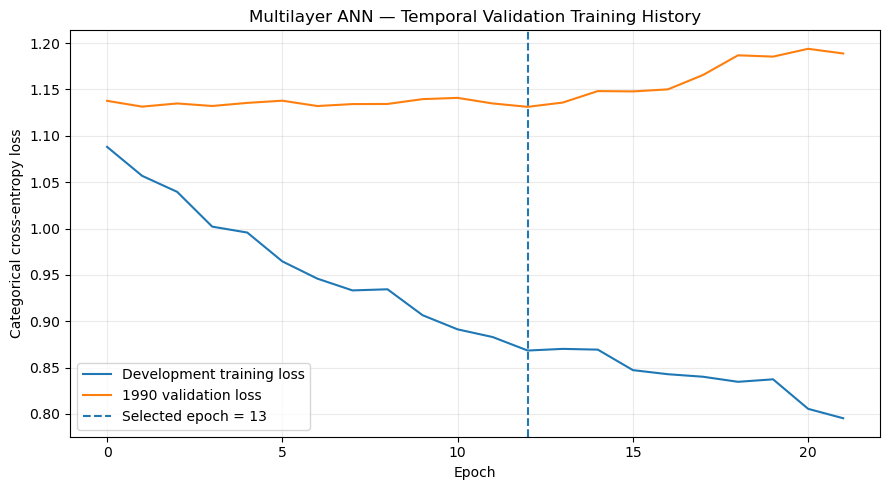

In [14]:
figures_dir = (
    project_root / "outputs" / "figures"
)

tables_dir = (
    project_root / "outputs" / "tables"
)

models_dir = (
    project_root / "outputs" / "models"
)

for folder in [
    figures_dir,
    tables_dir,
    models_dir,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )

plt.figure(figsize=(9, 5))

plt.plot(
    ann_history.history["loss"],
    label="Development training loss",
)

plt.plot(
    ann_history.history["val_loss"],
    label="1990 validation loss",
)

plt.axvline(
    best_ann_epoch - 1,
    linestyle="--",
    label=f"Selected epoch = {best_ann_epoch}",
)

plt.xlabel("Epoch")
plt.ylabel("Categorical cross-entropy loss")
plt.title(
    "Multilayer ANN — Temporal Validation Training History"
)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig(
    figures_dir /
    "ann_temporal_validation_loss.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## Fit final preprocessing on all historical training observations

In [17]:
final_preprocessor = make_preprocessor()

X_train_processed = (
    final_preprocessor.fit_transform(
        X_train_all
    )
)

X_test_processed = (
    final_preprocessor.transform(
        X_test
    )
)

feature_names = (
    final_preprocessor
    .get_feature_names_out()
)

feature_names = [
    name
    .replace("numeric__", "")
    .replace("categorical__", "")
    for name in feature_names
]

print(
    "Final training matrix:",
    X_train_processed.shape
)

print(
    "Final test matrix:",
    X_test_processed.shape
)

print("\nProcessed feature names:")
print(feature_names)

Final training matrix: (663, 14)
Final test matrix: (221, 14)

Processed feature names:
['population_at_reference', 'density_at_reference_per_km2', 'population_growth_prior_decade_pct', 'prior_decade_mean_temp_c', 'prior_decade_warming_c_per_decade', 'prior_decade_detrended_volatility_c', 'prior_decade_mean_temp_uncertainty_c', 'area_km2', 'continent_Africa', 'continent_Asia', 'continent_Europe', 'continent_North America', 'continent_Oceania', 'continent_South America']


## Train the final Decision Tree and evaluate on 2000

In [18]:
final_decision_tree = DecisionTreeClassifier(
    max_depth=best_dt_depth,
    min_samples_leaf=best_dt_leaf,
    random_state=RANDOM_STATE,
)

final_decision_tree.fit(
    X_train_processed,
    y_train_all,
)

dt_test_pred = final_decision_tree.predict(
    X_test_processed
)

dt_test_prob = final_decision_tree.predict_proba(
    X_test_processed
)

## Train the final Random Forest and evaluate on 2000

In [19]:
final_random_forest = RandomForestClassifier(
    n_estimators=500,
    max_depth=best_rf_depth,
    min_samples_leaf=best_rf_leaf,
    max_features=best_rf_features,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

final_random_forest.fit(
    X_train_processed,
    y_train_all,
)

rf_test_pred = final_random_forest.predict(
    X_test_processed
)

rf_test_prob = final_random_forest.predict_proba(
    X_test_processed
)

## Train the final Gaussian Naive Bayes and evaluate on 2000

In [20]:
final_naive_bayes = GaussianNB(
    var_smoothing=best_nb_smoothing
)

final_naive_bayes.fit(
    X_train_processed,
    y_train_all,
)

nb_test_pred = final_naive_bayes.predict(
    X_test_processed
)

nb_test_prob = final_naive_bayes.predict_proba(
    X_test_processed
)

## Train on final Multilayer ANN and evaluate on 2000

In [22]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(RANDOM_STATE)

final_ann = build_ann(
    X_train_processed.shape[1]
)

final_ann_history = final_ann.fit(
    X_train_processed,
    y_train_all,
    epochs=best_ann_epoch,
    batch_size=32,
    verbose=0,
)

ann_test_prob = final_ann.predict(
    X_test_processed,
    verbose=0,
)

ann_test_pred = np.argmax(
    ann_test_prob,
    axis=1,
)

print(
    "Final ANN training epochs:",
    best_ann_epoch
)

Final ANN training epochs: 13


# Compare all four models on the same 2000 test period

In [23]:
model_outputs = {
    "Decision Tree": (
        dt_test_pred,
        dt_test_prob,
    ),
    "Random Forest": (
        rf_test_pred,
        rf_test_prob,
    ),
    "Gaussian Naive Bayes": (
        nb_test_pred,
        nb_test_prob,
    ),
    "Multilayer ANN": (
        ann_test_pred,
        ann_test_prob,
    ),
}

evaluation_rows = []

for model_name, (
    predictions,
    probabilities,
) in model_outputs.items():
    evaluation_rows.append(
        evaluate_predictions(
            model_name=model_name,
            y_true=y_test,
            y_pred=predictions,
            y_probability=probabilities,
        )
    )

model_comparison = (
    pd.DataFrame(evaluation_rows)
    .sort_values(
        [
            "Macro F1",
            "Balanced Accuracy",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    model_comparison.style.format(
        {
            "Accuracy": "{:.3f}",
            "Balanced Accuracy": "{:.3f}",
            "Macro Precision": "{:.3f}",
            "Macro Recall": "{:.3f}",
            "Macro F1": "{:.3f}",
            "Macro ROC-AUC (OvR)": "{:.3f}",
        }
    )
)

model_comparison.to_csv(
    tables_dir /
    "updated_temporal_model_comparison.csv",
    index=False,
)

,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Macro ROC-AUC (OvR)
0,Decision Tree,0.457,0.454,0.470,0.454,0.460,0.627
1,Random Forest,0.398,0.415,0.415,0.415,0.407,0.652
2,Multilayer ANN,0.385,0.421,0.372,0.421,0.374,0.619
3,Gaussian Naive Bayes,0.407,0.457,0.522,0.457,0.343,0.630


Print per class classification report

In [24]:
for model_name, (
    predictions,
    probabilities,
) in model_outputs.items():

    print("\n" + "=" * 80)
    print(model_name)
    print("=" * 80)

    print(
        classification_report(
            y_test,
            predictions,
            labels=[0, 1, 2],
            target_names=CLASS_ORDER,
            zero_division=0,
            digits=3,
        )
    )


Decision Tree
              precision    recall  f1-score   support

         Low      0.569     0.468     0.513        62
      Medium      0.433     0.484     0.457        93
        High      0.409     0.409     0.409        66

    accuracy                          0.457       221
   macro avg      0.470     0.454     0.460       221
weighted avg      0.464     0.457     0.458       221


Random Forest
              precision    recall  f1-score   support

         Low      0.529     0.435     0.478        62
      Medium      0.351     0.280     0.311        93
        High      0.365     0.530     0.432        66

    accuracy                          0.398       221
   macro avg      0.415     0.415     0.407       221
weighted avg      0.405     0.398     0.394       221


Gaussian Naive Bayes
              precision    recall  f1-score   support

         Low      0.600     0.339     0.433        62
      Medium      0.600     0.032     0.061        93
        High      0.365

Plot Confusion Matrix

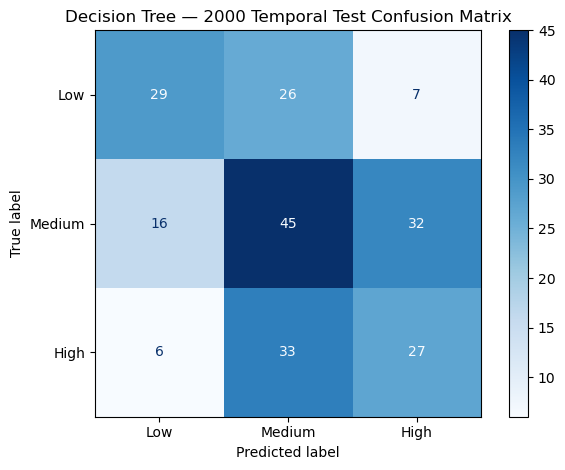

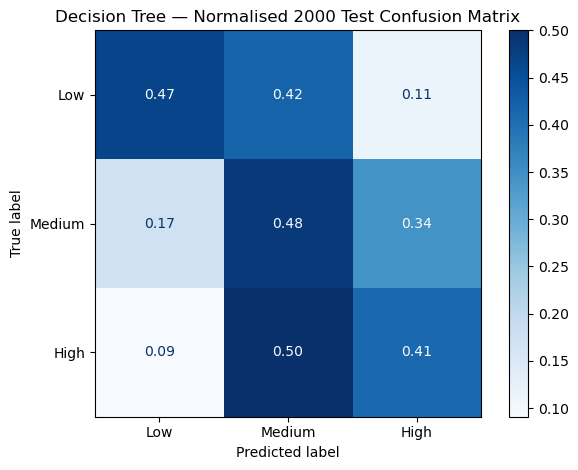

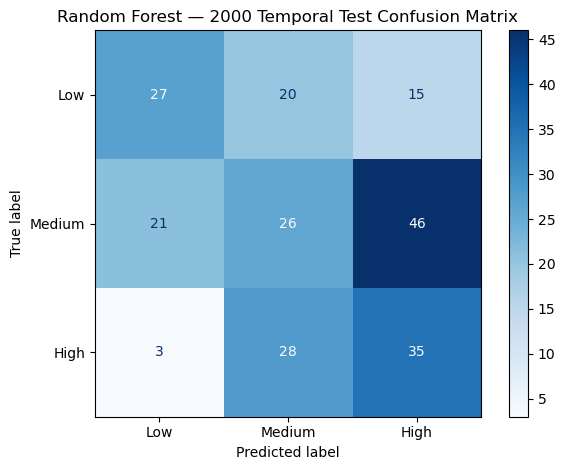

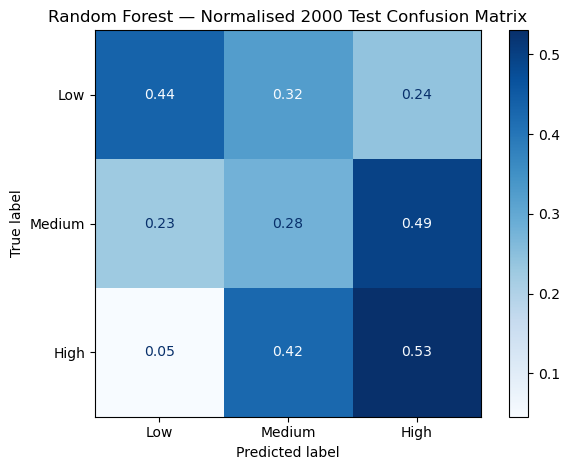

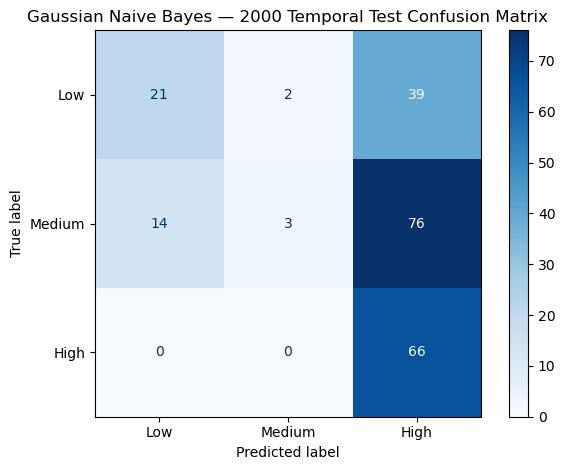

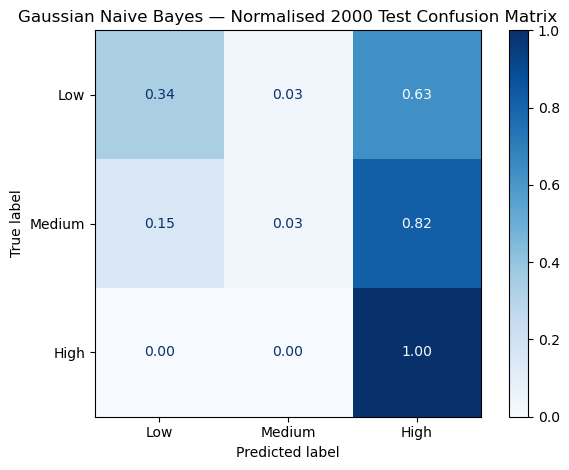

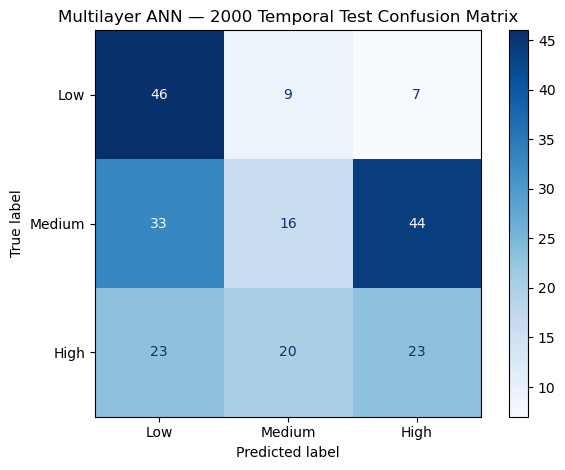

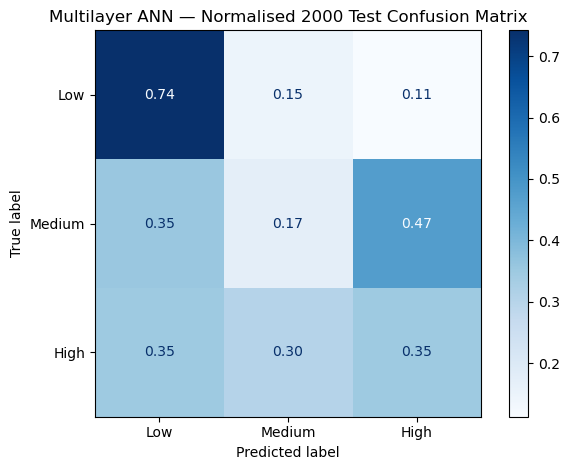

In [25]:
for model_name, (
    predictions,
    probabilities,
) in model_outputs.items():

    safe_name = (
        model_name
        .lower()
        .replace(" ", "_")
    )

    cm = confusion_matrix(
        y_test,
        predictions,
        labels=[0, 1, 2],
    )

    display_counts = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=CLASS_ORDER,
    )

    display_counts.plot(
        cmap="Blues",
        values_format="d",
    )

    plt.title(
        f"{model_name} — 2000 Temporal Test Confusion Matrix"
    )

    plt.tight_layout()

    plt.savefig(
        figures_dir /
        f"{safe_name}_test_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    cm_normalised = confusion_matrix(
        y_test,
        predictions,
        labels=[0, 1, 2],
        normalize="true",
    )

    display_normalised = (
        ConfusionMatrixDisplay(
            confusion_matrix=cm_normalised,
            display_labels=CLASS_ORDER,
        )
    )

    display_normalised.plot(
        cmap="Blues",
        values_format=".2f",
    )

    plt.title(
        f"{model_name} — Normalised 2000 Test Confusion Matrix"
    )

    plt.tight_layout()

    plt.savefig(
        figures_dir /
        f"{safe_name}_test_confusion_matrix_normalised.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

Plot the final model performance comparison

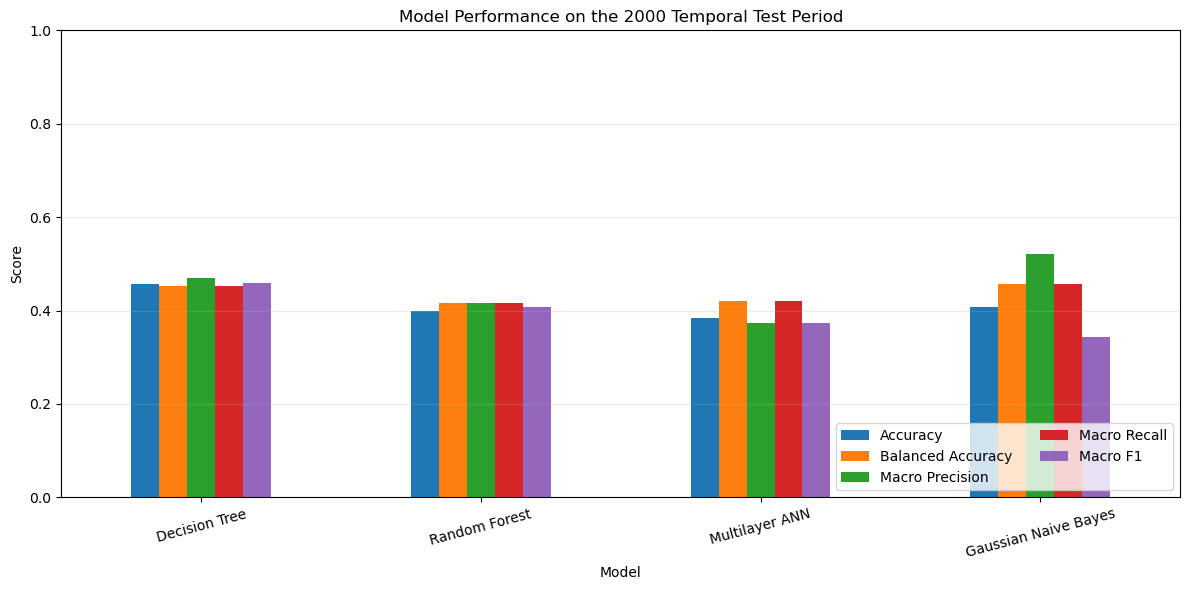

In [26]:
metrics_to_plot = [
    "Accuracy",
    "Balanced Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
]

plot_df = (
    model_comparison
    .set_index("Model")
    [metrics_to_plot]
)

ax = plot_df.plot(
    kind="bar",
    figsize=(12, 6),
    ylim=(0, 1),
    rot=15,
)

ax.set_title(
    "Model Performance on the 2000 Temporal Test Period"
)

ax.set_ylabel("Score")
ax.set_xlabel("Model")
ax.grid(
    axis="y",
    alpha=0.25,
)

plt.legend(
    loc="lower right",
    ncol=2,
)

plt.tight_layout()

plt.savefig(
    figures_dir /
    "updated_model_performance_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()